# Usporedba regulariziranih regresijskih metoda za predikciju plaće
**Modeli:** Ridge, Lasso i ElasticNet regresija

## Cilj projekta
Cilj ovog projekta je predvidjeti godišnju plaću zaposlenika na temelju demografskih i poslovnih značajki te usporediti tri regularizirane linearne regresijske metode: **Ridge (L2)**, **Lasso (L1)** i **ElasticNet (L1 + L2)**.

## Istraživačka pitanja
1. Koji model daje najbolju generalizaciju na testnom skupu podataka (RMSE, MAE)?
2. Kako regularizacija utječe na veličinu koeficijenata i složenost modela?
3. Provode li Lasso i ElasticNet selekciju značajki nakon one-hot kodiranja?

## Zašto regularizacija?
Kod problema s većim brojem (često koreliranih) značajki, obična linearna regresija može prenaučiti podatke.  
Regularizacija dodaje kazneni član funkciji gubitka, čime se:
- smanjuje prenaučenost
- povećava stabilnost modela
- omogućuje selekcija značajki (Lasso, ElasticNet)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

U ovom dijelu uvozimo biblioteke potrebne za obradu podataka (NumPy, pandas), vizualizaciju (matplotlib) te izgradnju i evaluaciju modela (scikit-learn).
Posebno je važno koristiti Pipeline i ColumnTransformer jer nam omogućuju da sve korake (imputacija, skaliranje, one-hot encoding i model) provodimo unutar jedne cjeline, čime se izbjegava data leakage (npr. da scaler “vidi” testni skup).

## Skup podataka
Koristi se tablični skup podataka koji sadrži informacije o zaposlenicima.

**Ciljna varijabla (target):**
- `Salary` – godišnja plaća zaposlenika

**Ulazne značajke (features):**
- Dob (Age)
- Spol (Gender)
- Razina obrazovanja (Education Level)
- Naziv radnog mjesta (Job Title)
- Godine radnog iskustva (Years of Experience)




In [3]:
df = pd.read_csv("data/salary_dataset.csv")

df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


## Provjera kvalitete podataka
U ovom koraku provjeravamo:
- dimenzije skupa podataka
- tipove podataka
- nedostajuće vrijednosti
- osnovne deskriptivne statistike




In [4]:
print("Dimenzije skupa:", df.shape)
display(df.info())
display(df.isna().sum())

display(df.describe().T)
display(df.describe(include=["object"]).T)

Dimenzije skupa: (375, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


None

,0
Age,2
Gender,2
Education Level,2
Job Title,2
Years of Experience,2
Salary,2


,count,mean,std,min,25%,50%,75%,max
Age,373.0,37.431635,7.069073,23.0,31.0,36.0,44.0,53.0
Years of Experience,373.0,10.030831,6.557007,0.0,4.0,9.0,15.0,25.0
Salary,373.0,100577.345845,48240.013482,350.0,55000.0,95000.0,140000.0,250000.0


,count,unique,top,freq
Gender,373,2,Male,194
Education Level,373,3,Bachelor's,224
Job Title,373,174,Director of Marketing,12


Cilj je otkriti potencijalne probleme (npr. NaN vrijednosti) i odlučiti o strategiji čišćenja.
U mom slučaju postoje nedostajuće vrijednosti u više stupaca pa kasnije koristim SimpleImputer (median za numeričke, most_frequent za kategorijske).

## Definicija značajki i ciljne varijable
- **y** predstavlja ciljnu varijablu – `Salary`
- **X** sadrži sve ostale stupce kao ulazne značajke

Preprocesiranje će se provoditi unutar pipeline-a kako bi se izbjegao data leakage.


In [5]:
target = "Salary"
X = df.drop(columns=[target])
y = df[target]

X.head()

,Age,Gender,Education Level,Job Title,Years of Experience
0,32.0,Male,Bachelor's,Software Engineer,5.0
1,28.0,Female,Master's,Data Analyst,3.0
2,45.0,Male,PhD,Senior Manager,15.0
3,36.0,Female,Bachelor's,Sales Associate,7.0
4,52.0,Male,Master's,Director,20.0


## Podjela na skup za učenje i testiranje
Podaci se dijele na:
- **80%** za učenje modela
- **20%** za testiranje

Testni skup koristi se isključivo za konačnu evaluaciju modela. <br>
Testni skup se ne smije koristiti za odabir hiperparametara, jer bi to dovelo do “preoptimiziranja” i nerealno dobrih rezultata.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((300, 5), (75, 5))

## Eksplorativna analiza podataka (EDA)
Provodi se osnovna analiza:
- distribucija plaća
- odnos plaće i godina iskustva

Cilj je steći uvid u podatke i provjeriti linearnost odnosa.


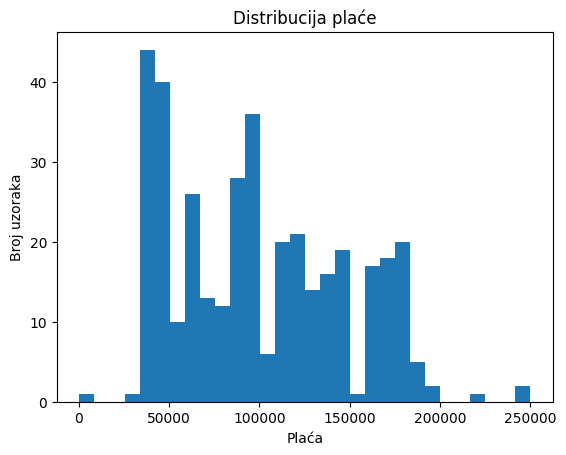

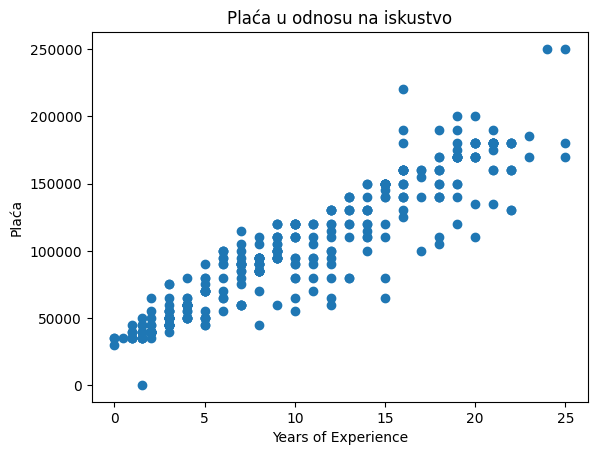

In [7]:
plt.hist(y, bins=30)
plt.xlabel("Plaća")
plt.ylabel("Broj uzoraka")
plt.title("Distribucija plaće")
plt.show()

exp_cols = [c for c in X.columns if "experience" in c.lower()]
if exp_cols:
    plt.scatter(df[exp_cols[0]], y)
    plt.xlabel(exp_cols[0])
    plt.ylabel("Plaća")
    plt.title("Plaća u odnosu na iskustvo")
    plt.show()


Histogram pokazuje da distribucija plaća nije potpuno simetrična, već je blago desno asimetrična, s većinom vrijednosti u srednjem rasponu i manjim brojem vrlo visokih plaća. Prisutnost ekstremnih vrijednosti (outliera) može negativno utjecati na modele i objašnjava zašto je RMSE veći od MAE. Ova distribucija opravdava primjenu regularizacije kako bi se smanjio utjecaj ekstremnih vrijednosti. <br>

Scatter graf pokazuje jasan pozitivan, približno linearan odnos između godina iskustva i plaće. Uz rast iskustva povećava se i varijabilnost plaće, što upućuje na utjecaj dodatnih faktora poput radne pozicije i razine obrazovanja. Ovakav odnos opravdava korištenje linearnih regresijskih modela kao osnovnog pristupa.

## Preprocesiranje podataka
Zbog različitih tipova podataka koristi se **ColumnTransformer**.

### Numeričke značajke
- popunjavanje nedostajućih vrijednosti (medijan)
- standardizacija (StandardScaler)

### Kategorijske značajke
- popunjavanje najčešćom vrijednošću
- one-hot kodiranje

Standardizacija je nužna jer regularizacija ovisi o skali značajki.


In [8]:
num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object"]).columns

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
])

## Metode evaluacije
Koriste se sljedeće metrike:
- **MAE** – prosječna apsolutna pogreška
- **RMSE** – kvadratni korijen srednje kvadratne pogreške
- **R²** – objašnjena varijanca


In [9]:
def evaluate(model, X_test, y_test):
    preds = model.predict(X_test)
    return (
        mean_absolute_error(y_test, preds),
        np.sqrt(mean_squared_error(y_test, preds)),
        r2_score(y_test, preds)
    )

Cilj je pronaći model s najboljom generalizacijom na testnom skupu, uz razumne koeficijente i stabilnost.

## Bazni modeli
1. **DummyRegressor** – predviđa srednju vrijednost plaće
2. **LinearRegression** – linearna regresija bez regularizacije

Ovi modeli služe kao referenca.


In [10]:
results = {}

y_train_imputed = y_train.fillna(y_train.median())
y_test_imputed = y_test.fillna(y_train.median())

dummy = Pipeline([
    ("preprocess", preprocess),
    ("model", DummyRegressor())
])
dummy.fit(X_train, y_train_imputed)
results["Dummy"] = evaluate(dummy, X_test, y_test_imputed)

linreg = Pipeline([
    ("preprocess", preprocess),
    ("model", LinearRegression())
])
linreg.fit(X_train, y_train_imputed)
results["LinearRegression"] = evaluate(linreg, X_test, y_test_imputed)

pd.DataFrame(results, index=["MAE", "RMSE", "R2"]).T

,MAE,RMSE,R2
Dummy,40915.726667,49235.914638,-0.000469
LinearRegression,11795.389621,18224.617364,0.862926


Ako regularizirani modeli ne poboljšaju rezultate u odnosu na LinearRegression, to može značiti da:
podaci nisu dovoljno “teški” (malo multikolinearnosti), ili
hiperparametri nisu optimalni, ili
je potrebno više značajki / nelinearni model.

## Regularizirani regresijski modeli
- **Ridge (L2)** – smanjuje koeficijente, ali ih ne poništava
- **Lasso (L1)** – može postaviti koeficijente na nulu
- **ElasticNet** – kombinacija Ridge i Lasso pristupa

Hiperparametri se podešavaju pomoću **GridSearchCV** uz 5-struku unakrsnu validaciju.
Kao scoring koristim neg_root_mean_squared_error kako bih direktno optimizirala RMSE kroz unakrsnu validaciju


In [11]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_gs = GridSearchCV(
    Pipeline([("preprocess", preprocess), ("model", Ridge())]),
    {"model__alpha": [0.01, 0.1, 1, 10, 100, 1000]},
    cv=cv,
    scoring="neg_root_mean_squared_error"
)
ridge_gs.fit(X_train, y_train_imputed)

lasso_gs = GridSearchCV(
    Pipeline([("preprocess", preprocess),
              ("model", Lasso(max_iter=1000000, tol=1e-3, selection="random"))]),
    {"model__alpha": [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]},
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

lasso_gs.fit(X_train, y_train_imputed)


enet_gs = GridSearchCV(
    Pipeline([("preprocess", preprocess),
              ("model", ElasticNet(max_iter=1000000, tol=1e-3, selection="random"))]),
    {"model__alpha": [1e-4, 1e-3, 1e-2, 1e-1, 1, 10],
     "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]},
    cv=cv,
    scoring="neg_root_mean_squared_error"
)
enet_gs.fit(X_train, y_train_imputed)


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Age', 'Years of Experience'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['Gender', 'Education Level', 'Job Title'], dtype='object'))])),
                                       ('model',
                                        ElasticNet(max_iter=1000000,
                                                   selection='random',
                                                   tol=0.001))]),
             param_grid={'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10],
                         'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
             scoring='neg_root_mean_squared_error')

In [12]:
best_ridge_model = ridge_gs.best_estimator_
best_lasso_model = lasso_gs.best_estimator_
best_enet_model  = enet_gs.best_estimator_

metrics = {}
best_params = {}

best_params["Ridge"] = ridge_gs.best_params_
best_params["Lasso"] = lasso_gs.best_params_
best_params["ElasticNet"] = enet_gs.best_params_

metrics["Dummy"] = results["Dummy"]
metrics["LinearRegression"] = results["LinearRegression"]

metrics["Ridge"] = evaluate(best_ridge_model, X_test, y_test_imputed)
metrics["Lasso"] = evaluate(best_lasso_model, X_test, y_test_imputed)
metrics["ElasticNet"] = evaluate(best_enet_model, X_test, y_test_imputed)

metrics_df = pd.DataFrame(metrics, index=["MAE", "RMSE", "R2"]).T
display(metrics_df.sort_values("RMSE"))

print("\nBest Parameters:")
for k, v in best_params.items():
    print(f"{k}: {v}")


,MAE,RMSE,R2
ElasticNet,9675.929143,14874.622642,0.908687
Ridge,9731.856541,14983.144252,0.907350
Lasso,9993.197314,15713.815637,0.898093
LinearRegression,11795.389621,18224.617364,0.862926
Dummy,40915.726667,49235.914638,-0.000469



Best Parameters:
Ridge: {'model__alpha': 1}
Lasso: {'model__alpha': 10}
ElasticNet: {'model__alpha': 0.01, 'model__l1_ratio': 0.3}


Nakon što GridSearchCV pronađe najbolje hiperparametre, preuzimam najbolje pipeline modele preko best_estimator_ i radim konačnu evaluaciju na testnom skupu.
!!!testni skup se koristi samo jednom, na kraju, kako bi procjena generalizacije bila realna.
U tablici uspoređujem:


*   Dummy (baseline – predviđa prosjek)
*   LinearRegression (bez regularizacije)
*   Ridge / Lasso / ElasticNet (najbolje varijante iz CV) <br>

Na temelju rezultata u mom slučaju vidim da regularizacija značajno poboljšava performanse u odnosu na običnu linearnu regresiju:

*   ElasticNet ima najbolji rezultat (najniži RMSE i najveći R²),
* Ridge je vrlo blizu,
* Lasso je nešto slabiji, ali nudi jaču selekciju značajki.







## Konačna evaluacija
Ovdje prikazujem završne rezultate sortirane po RMSE kako bih jasno vidio koji model najbolje generalizira.
U kontekstu ovog projekta, model s najmanjim RMSE smatram najboljim za predikciju plaće jer RMSE jače kažnjava velika odstupanja (što je bitno kad postoje outlieri u plaćama).

In [13]:
final_results = {
    "Dummy": results["Dummy"],
    "LinearRegression": results["LinearRegression"],
    "Ridge": evaluate(ridge_gs.best_estimator_, X_test, y_test_imputed),
    "Lasso": evaluate(lasso_gs.best_estimator_, X_test, y_test_imputed),
    "ElasticNet": evaluate(enet_gs.best_estimator_, X_test, y_test_imputed)
}

final_df = pd.DataFrame(
    final_results,
    index=["MAE", "RMSE", "R2"]
).T

final_df = final_df.sort_values("RMSE")
display(final_df)

,MAE,RMSE,R2
ElasticNet,9675.929143,14874.622642,0.908687
Ridge,9731.856541,14983.144252,0.907350
Lasso,9993.197314,15713.815637,0.898093
LinearRegression,11795.389621,18224.617364,0.862926
Dummy,40915.726667,49235.914638,-0.000469


Osim prediktivne točnosti, analiziram i koeficijente modela kako bih razumio koje značajke imaju najveći utjecaj na predikciju plaće. Zbog one-hot kodiranja kategorijske varijable (npr. Job Title) pretvorene su u veliki broj binarnih značajki, pa najprije dohvaćam njihova stvarna imena pomoću get_feature_names_out(). <br>

Za svaki model analiziram vrijednosti koeficijenata i broj nenultih koeficijenata, koji predstavlja mjeru složenosti modela. Ridge regresija ne postavlja koeficijente na nulu, već ih samo smanjuje, zbog čega ima veći broj aktivnih značajki. Lasso koristi L1 regularizaciju i može postaviti dio koeficijenata na nulu, čime provodi selekciju značajki. ElasticNet kombinira L1 i L2 regularizaciju, a u ovom slučaju se zbog manjeg l1_ratio ponaša slično Ridge regresiji. <br>

Znak koeficijenta označava smjer utjecaja značajke: pozitivan koeficijent povećava, a negativan smanjuje predviđenu plaću u odnosu na referentnu kategoriju kod one-hot kodiranja. Rezultati pokazuju da rukovodeće i tehničke pozicije imaju pozitivan, dok administrativne pozicije imaju negativan utjecaj, što je u skladu s realnim očekivanjima.

In [14]:
feature_names = ridge_gs.best_estimator_.named_steps["preprocess"].get_feature_names_out()

def show_coefs(model, name, top_n=10):
    coefs = model.named_steps["model"].coef_
    df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefs
    })
    df["AbsCoeff"] = df["Coefficient"].abs()
    df = df.sort_values("AbsCoeff", ascending=False)

    print(f"\n{name}: non-zero coefficients = {np.sum(coefs != 0)}")
    display(df.head(top_n)[["Feature", "Coefficient"]])

show_coefs(ridge_gs.best_estimator_, "Ridge")
show_coefs(lasso_gs.best_estimator_, "Lasso")
show_coefs(enet_gs.best_estimator_, "ElasticNet")



Ridge: non-zero coefficients = 156


,Feature,Coefficient
12,cat__Job Title_Chief Data Officer,33015.164514
13,cat__Job Title_Chief Technology Officer,27056.665467
8,cat__Job Title_Administrative Assistant,-23803.304195
0,num__Age,23316.439304
129,cat__Job Title_Senior Product Manager,22165.856493
52,cat__Job Title_Junior Business Operations Analyst,-20990.561219
82,cat__Job Title_Office Manager,-20269.977261
153,cat__Job Title_VP of Finance,20115.319134
37,cat__Job Title_Event Coordinator,-17071.156147
151,cat__Job Title_Training Specialist,-15753.933303



Lasso: non-zero coefficients = 136


,Feature,Coefficient
12,cat__Job Title_Chief Data Officer,72577.922128
13,cat__Job Title_Chief Technology Officer,63671.905837
153,cat__Job Title_VP of Finance,48047.910883
82,cat__Job Title_Office Manager,-38749.128361
154,cat__Job Title_VP of Operations,38071.285314
84,cat__Job Title_Operations Director,37453.315234
8,cat__Job Title_Administrative Assistant,-35641.850754
27,cat__Job Title_Director of Engineering,33524.206606
25,cat__Job Title_Director,32245.554983
52,cat__Job Title_Junior Business Operations Analyst,-31838.499063



ElasticNet: non-zero coefficients = 156


,Feature,Coefficient
0,num__Age,23055.879531
12,cat__Job Title_Chief Data Officer,21047.940224
129,cat__Job Title_Senior Product Manager,18672.334703
8,cat__Job Title_Administrative Assistant,-17166.666605
13,cat__Job Title_Chief Technology Officer,16903.927554
4,cat__Education Level_Bachelor's,-15116.269934
52,cat__Job Title_Junior Business Operations Analyst,-14994.818386
1,num__Years of Experience,13326.857724
82,cat__Job Title_Office Manager,-13156.203001
37,cat__Job Title_Event Coordinator,-12227.936932


Ovdje ispisujem najbolje pronađene hiperparametre iz GridSearchCV kako bih mogla:


*   dokumentirati izbor modela
*   objasniti jačinu regularizacije
*   usporediti ponašanje Ridge/Lasso/ElasticNet


U ovom slučaju:


*   Ridge: alpha=1 (umjerena regularizacija)
*   Lasso: alpha=10 (jača regularizacija, odnosno, više rezanja koeficijenata)
*   ElasticNet: alpha=0,01, l1_ratio=0,3 (model je više "Ridge-like" (70% L2, 30% L1) što često pomaže kad su značajke korelirane









In [15]:
print("Best hyperparameters:")
print("Ridge:", ridge_gs.best_params_)
print("Lasso:", lasso_gs.best_params_)
print("ElasticNet:", enet_gs.best_params_)


Best hyperparameters:
Ridge: {'model__alpha': 1}
Lasso: {'model__alpha': 10}
ElasticNet: {'model__alpha': 0.01, 'model__l1_ratio': 0.3}


## Zaključak
Cilj ovog projekta bio je usporediti regularizirane linearne regresijske metode (Ridge, Lasso i ElasticNet) u zadatku predikcije godišnje plaće zaposlenika na temelju demografskih i poslovnih značajki. Poseban naglasak stavljen je na utjecaj regularizacije na generalizaciju modela, stabilnost koeficijenata i selekciju značajki u prisutnosti velikog broja one-hot kodiranih varijabli. <br>

Rezultati pokazuju da regularizacija značajno poboljšava performanse modela u odnosu na običnu linearnu regresiju bez regularizacije. Svi regularizirani modeli ostvaruju niži RMSE i viši R² u usporedbi s referentnim (baseline) modelima, što potvrđuje da regularizacija uspješno smanjuje prenaučenost i povećava sposobnost generalizacije na neviđene podatke. <br>

ElasticNet se pokazao kao najbolji model prema kriteriju RMSE i R², što sugerira da kombinacija L1 i L2 regularizacije daje dobar kompromis između stabilnosti i selekcije značajki. Odabrani omjer (l1_ratio = 0.3) pokazuje da je u ovom problemu korisnija jača L2 komponenta, uz umjerenu L1 komponentu koja doprinosi redukciji broja aktivnih značajki. <br>

Ridge regresija ostvaruje vrlo slične rezultate ElasticNetu, uz nešto veći RMSE, ali pokazuje visoku stabilnost koeficijenata. Zbog toga Ridge predstavlja dobar izbor kada je cilj pouzdan i robustan model, osobito u situacijama s jakom korelacijom među značajkama. <br>

Lasso regresija postiže nešto slabije prediktivne rezultate, ali se ističe po mogućnosti automatske selekcije značajki, što je vidljivo kroz manji broj nenultih koeficijenata. To Lasso čini korisnim kada je interpretabilnost modela i smanjenje složenosti važnije od minimalne pogreške predikcije. <br>

Analiza koeficijenata pokazala je da značajke povezane s radnim iskustvom, dobi i određenim radnim pozicijama (Job Title) imaju najveći utjecaj na predikciju plaće. One-hot kodiranje rezultiralo je velikim brojem kategorijskih značajki, zbog čega je regularizacija imala ključnu ulogu u kontroli složenosti modela. <br>

Zaključno, ovaj projekt potvrđuje da su regularizirane linearne regresijske metode prikladan i učinkovit pristup za predikciju plaće u problemskim postavkama s velikim brojem (često koreliranih) značajki. Izbor između Ridge, Lasso i ElasticNet modela ovisi o prioritetima zadatka: <br>


*   ElasticNet za najbolju ukupnu prediktivnu točnost
*   Ridge za stabilnost i robusnost
*   Lasso za selekciju značajki i jednostavniju interpretaciju

